In [12]:
from collections import Counter
from pathlib import Path
import random

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from PIL import Image
from tqdm.notebook import tqdm

# 1. Dataset Path

In [13]:
DATASET_DIR = Path(
    "/workspace/data/raw/authenticity/"
    "Bangladeshi Counterfeit Currency Image Dataset/"
    "Denomination-wise Distribution"
)

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

print(f"Dataset Path: {DATASET_DIR}")
print(f"Exists: {DATASET_DIR.exists()}")

Dataset Path: /workspace/data/raw/authenticity/Bangladeshi Counterfeit Currency Image Dataset/Denomination-wise Distribution
Exists: True


# 2. Dataset Structure Inspection

In [14]:
for class_dir in sorted(DATASET_DIR.iterdir()):

    if not class_dir.is_dir():
        continue

    image_count = sum(
        1
        for file_path in class_dir.iterdir()
        if file_path.suffix.lower() in IMAGE_EXTENSIONS
    )

    print(f"{class_dir.name}: {image_count} images")

1000 BDT Counterfeit: 55 images
1000 BDT Genuine: 370 images
500 BDT Counterfeit: 32 images
500 BDT Genuine: 829 images


# 3. Metadata Construction

In [15]:
records: list[dict[str, object]] = []

for class_dir in sorted(DATASET_DIR.iterdir()):

    if not class_dir.is_dir():
        continue

    folder_name = class_dir.name

    denomination = folder_name.split()[0]
    authenticity = folder_name.split()[-1]

    for image_path in sorted(class_dir.iterdir()):

        if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue

        records.append(
            {
                "image_path": image_path,
                "folder": folder_name,
                "denomination": denomination,
                "authenticity": authenticity,
            }
        )

df = pd.DataFrame(records)

print(f"Total Images: {len(df)}")

df.head()

Total Images: 1286


,image_path,folder,denomination,authenticity
0,/workspace/data/raw/authenticity/Bangladeshi C...,1000 BDT Counterfeit,1000,Counterfeit
1,/workspace/data/raw/authenticity/Bangladeshi C...,1000 BDT Counterfeit,1000,Counterfeit
2,/workspace/data/raw/authenticity/Bangladeshi C...,1000 BDT Counterfeit,1000,Counterfeit
3,/workspace/data/raw/authenticity/Bangladeshi C...,1000 BDT Counterfeit,1000,Counterfeit
4,/workspace/data/raw/authenticity/Bangladeshi C...,1000 BDT Counterfeit,1000,Counterfeit


# 4. Dataset Overview

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1286 entries, 0 to 1285
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   image_path    1286 non-null   object
 1   folder        1286 non-null   str   
 2   denomination  1286 non-null   str   
 3   authenticity  1286 non-null   str   
dtypes: object(1), str(3)
memory usage: 73.2+ KB


In [17]:
df.head()

,image_path,folder,denomination,authenticity
0,/workspace/data/raw/authenticity/Bangladeshi C...,1000 BDT Counterfeit,1000,Counterfeit
1,/workspace/data/raw/authenticity/Bangladeshi C...,1000 BDT Counterfeit,1000,Counterfeit
2,/workspace/data/raw/authenticity/Bangladeshi C...,1000 BDT Counterfeit,1000,Counterfeit
3,/workspace/data/raw/authenticity/Bangladeshi C...,1000 BDT Counterfeit,1000,Counterfeit
4,/workspace/data/raw/authenticity/Bangladeshi C...,1000 BDT Counterfeit,1000,Counterfeit


In [18]:
df.tail()

,image_path,folder,denomination,authenticity
1281,/workspace/data/raw/authenticity/Bangladeshi C...,500 BDT Genuine,500,Genuine
1282,/workspace/data/raw/authenticity/Bangladeshi C...,500 BDT Genuine,500,Genuine
1283,/workspace/data/raw/authenticity/Bangladeshi C...,500 BDT Genuine,500,Genuine
1284,/workspace/data/raw/authenticity/Bangladeshi C...,500 BDT Genuine,500,Genuine
1285,/workspace/data/raw/authenticity/Bangladeshi C...,500 BDT Genuine,500,Genuine


In [19]:
df.isnull().sum()

image_path      0
folder          0
denomination    0
authenticity    0
dtype: int64

In [20]:
print(f"Unique folders        : {df['folder'].nunique()}")
print(f"Unique denominations  : {df['denomination'].nunique()}")
print(f"Unique authenticity   : {df['authenticity'].nunique()}")

Unique folders        : 4
Unique denominations  : 2
Unique authenticity   : 2


In [21]:
authenticity_counts = (
    df["authenticity"]
    .value_counts()
    .sort_index()
)

authenticity_counts

authenticity
Counterfeit      87
Genuine        1199
Name: count, dtype: int64

# 5. Authenticity 

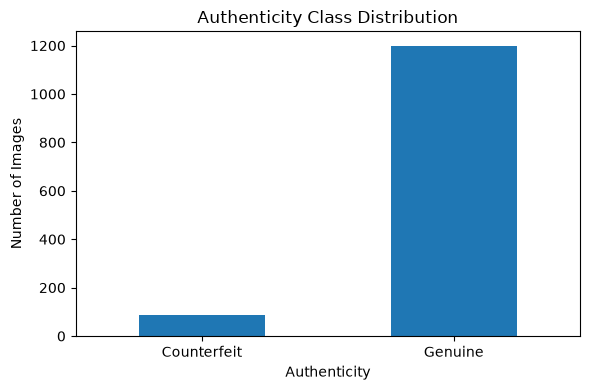

In [22]:
plt.figure(figsize=(6, 4))

authenticity_counts.plot(
    kind="bar",
    rot=0,
)

plt.title("Authenticity Class Distribution")
plt.xlabel("Authenticity")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

# 6. Denomination Distribution

In [23]:
denomination_counts = (
    df["denomination"]
    .value_counts()
    .sort_index()
)

denomination_counts

denomination
1000    425
500     861
Name: count, dtype: int64

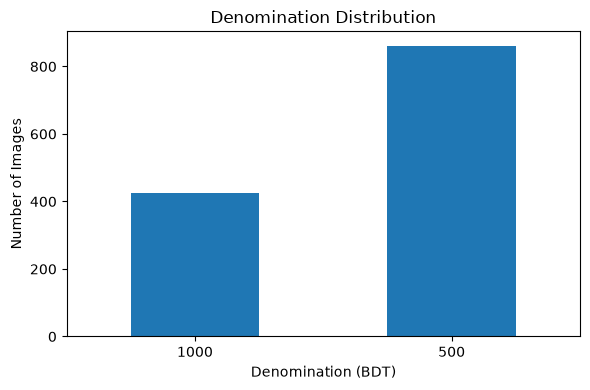

In [24]:
plt.figure(figsize=(6, 4))

denomination_counts.plot(
    kind="bar",
    rot=0,
)

plt.title("Denomination Distribution")
plt.xlabel("Denomination (BDT)")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

# 7. Authenticity x Denomination

In [25]:
cross_table = pd.crosstab(
    index=df["denomination"],
    columns=df["authenticity"],
)

cross_table

authenticity,Counterfeit,Genuine
denomination,,
1000,55,370
500,32,829


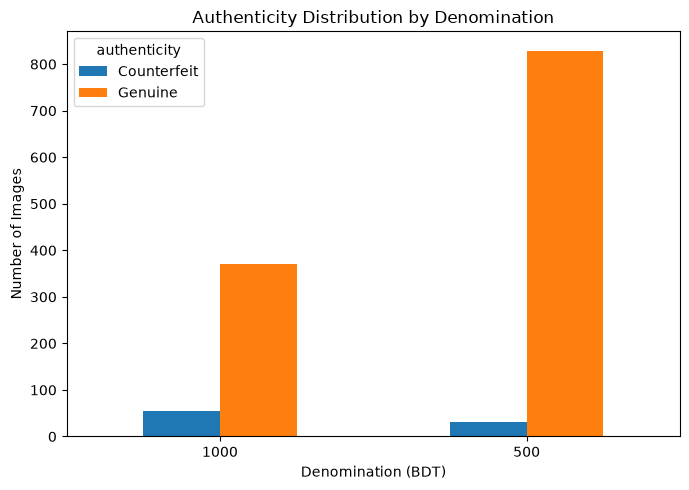

In [26]:
cross_table.plot(
    kind="bar",
    figsize=(7, 5),
)

plt.title("Authenticity Distribution by Denomination")
plt.xlabel("Denomination (BDT)")
plt.ylabel("Number of Images")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# 8. Image Dimension Analysis

In [27]:
widths: list[int] = []
heights: list[int] = []

for image_path in tqdm(df["image_path"], desc="Reading image dimensions"):

    with Image.open(image_path) as image:
        widths.append(image.width)
        heights.append(image.height)

df["width"] = widths
df["height"] = heights

df[["width", "height"]].head()

Reading image dimensions:   0%|          | 0/1286 [00:00<?, ?it/s]

,width,height
0,4000,3000
1,4000,3000
2,4000,3000
3,4000,3000
4,4000,3000


In [28]:
df[["width", "height"]].describe()

,width,height
count,1286.000000,1286.000000
mean,3552.116641,3331.276827
std,982.167025,838.141465
min,512.000000,512.000000
25%,3000.000000,3000.000000
50%,4000.000000,3472.000000
75%,4000.000000,4000.000000
max,4640.000000,4000.000000


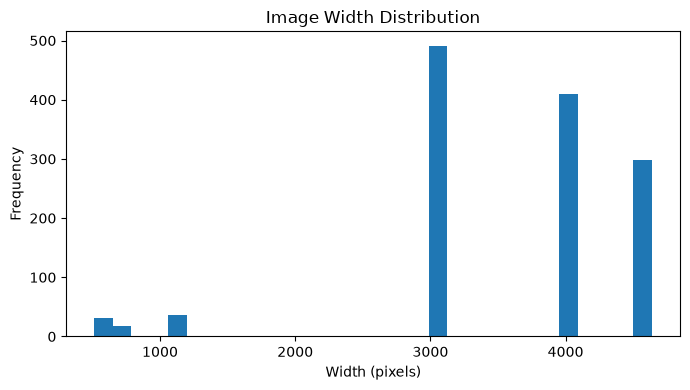

In [29]:
plt.figure(figsize=(7, 4))

plt.hist(
    df["width"],
    bins=30,
)

plt.title("Image Width Distribution")
plt.xlabel("Width (pixels)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

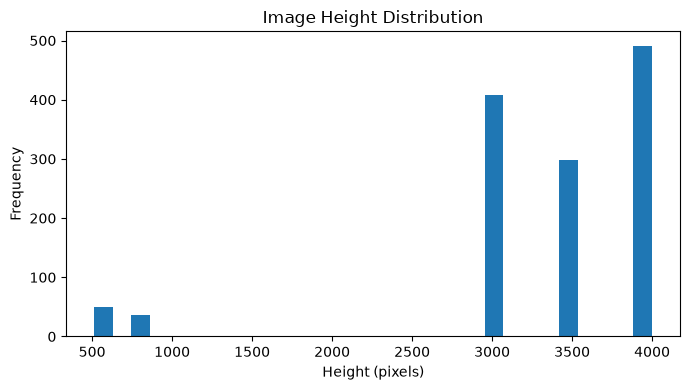

In [30]:
plt.figure(figsize=(7, 4))

plt.hist(
    df["height"],
    bins=30,
)

plt.title("Image Height Distribution")
plt.xlabel("Height (pixels)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

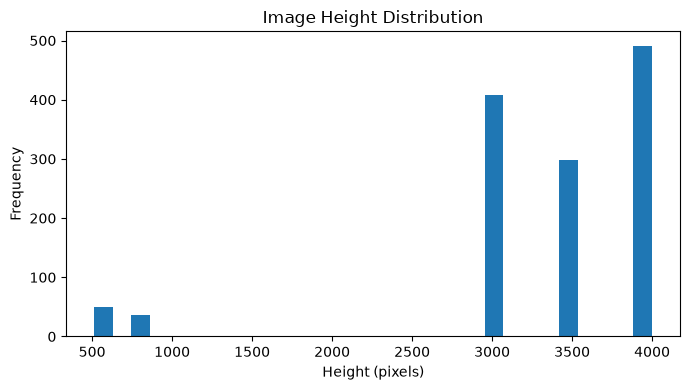

In [31]:
plt.figure(figsize=(7, 4))

plt.hist(
    df["height"],
    bins=30,
)

plt.title("Image Height Distribution")
plt.xlabel("Height (pixels)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [32]:
image_sizes = (
    df[["width", "height"]]
    .value_counts()
    .reset_index(name="count")
)

image_sizes

,width,height,count
0,3000,4000,491
1,4000,3000,408
2,4640,3472,299
3,512,512,32
4,1117,784,20
5,774,580,18
6,1118,781,17
7,4000,2113,1


In [34]:
df["aspect_ratio"] = df["width"] / df["height"]

df["aspect_ratio"].describe()

count    1286.000000
mean        1.106205
std         0.285768
min         0.750000
25%         0.750000
50%         1.333333
75%         1.336406
max         1.893043
Name: aspect_ratio, dtype: float64

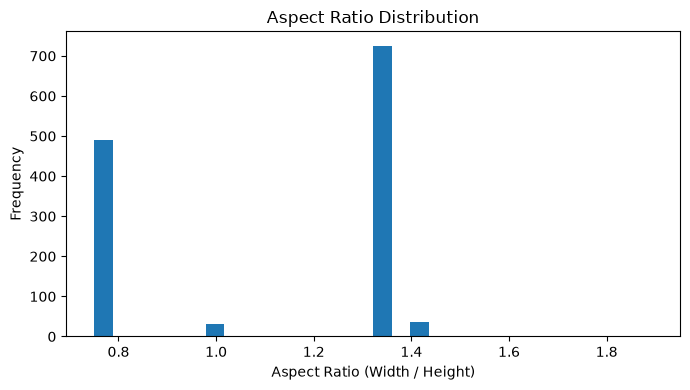

In [35]:
plt.figure(figsize=(7, 4))

plt.hist(
    df["aspect_ratio"],
    bins=30,
)

plt.title("Aspect Ratio Distribution")
plt.xlabel("Aspect Ratio (Width / Height)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

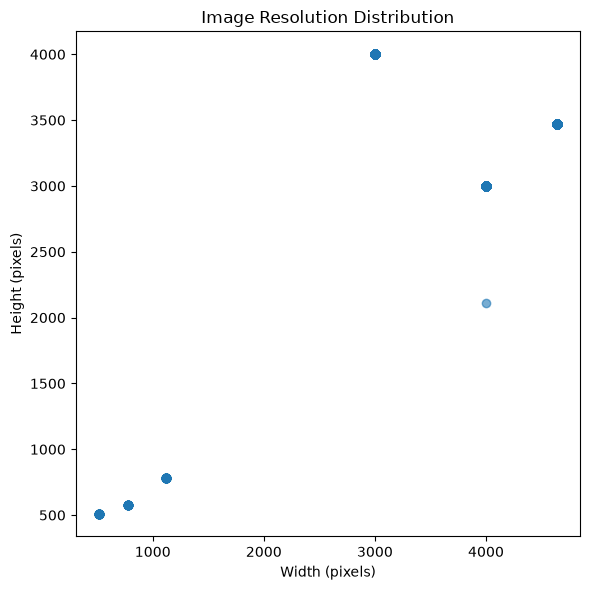

In [36]:
plt.figure(figsize=(6, 6))

plt.scatter(
    df["width"],
    df["height"],
    alpha=0.6,
)

plt.title("Image Resolution Distribution")
plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")

plt.tight_layout()
plt.show()

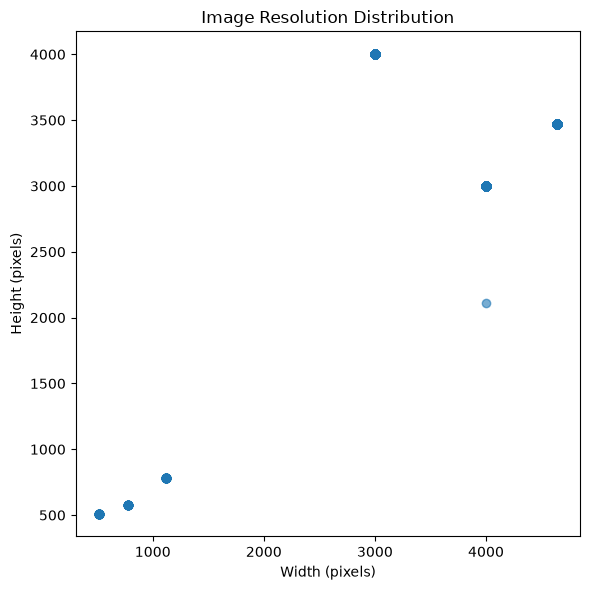

In [37]:
plt.figure(figsize=(6, 6))

plt.scatter(
    df["width"],
    df["height"],
    alpha=0.6,
)

plt.title("Image Resolution Distribution")
plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")

plt.tight_layout()
plt.show()

# 9. Colour Mode Analysis

In [43]:
image_modes: Counter[str] = Counter()

for image_path in tqdm(df["image_path"], desc="Checking image modes"):

    with Image.open(image_path) as image:
        image_modes[image.mode] += 1

image_modes

Checking image modes:   0%|          | 0/1286 [00:00<?, ?it/s]

Counter({'RGB': 1284, 'RGBA': 2})

# 10. Random Sample Visualization

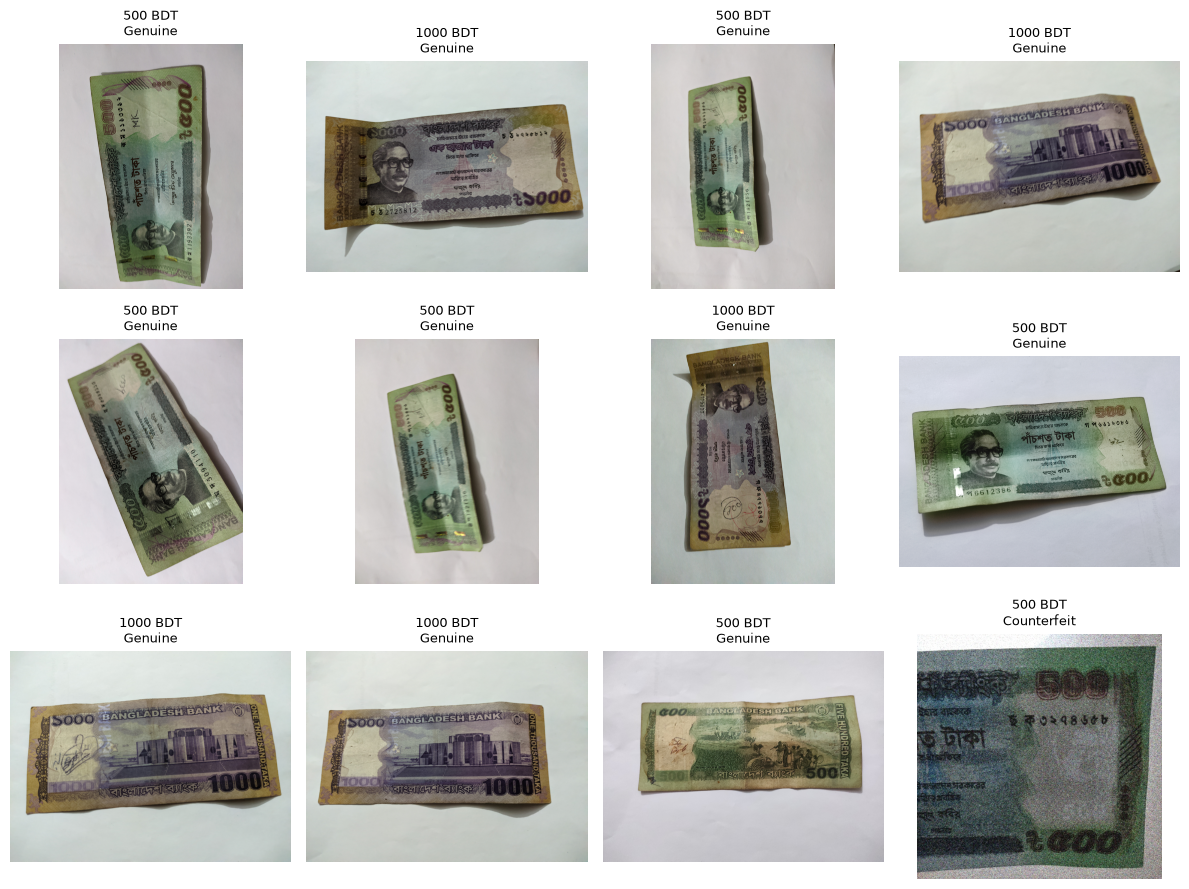

In [38]:
sample_df = df.sample(
    n=12,
    random_state=42,
)

plt.figure(figsize=(12, 9))

for index, (_, row) in enumerate(sample_df.iterrows(), start=1):

    with Image.open(row["image_path"]) as image:

        plt.subplot(3, 4, index)
        plt.imshow(image)

    plt.title(
        f'{row["denomination"]} BDT\n{row["authenticity"]}',
        fontsize=9,
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

# 11. Corrupted image Detection

In [39]:
corrupted_images: list[Path] = []

for image_path in tqdm(df["image_path"], desc="Checking corrupted images"):

    try:
        with Image.open(image_path) as image:
            image.verify()

    except Exception:
        corrupted_images.append(image_path)

print(f"Corrupted Images: {len(corrupted_images)}")

Checking corrupted images:   0%|          | 0/1286 [00:00<?, ?it/s]

Corrupted Images: 0


# 12. Dataset Mean & Standard Deviation

In [40]:
channel_means: list[np.ndarray] = []
channel_stds: list[np.ndarray] = []

for image_path in tqdm(df["image_path"], desc="Computing dataset statistics"):

    image = cv2.imread(str(image_path))

    if image is None:
        continue

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = image.astype(np.float32) / 255.0

    channel_means.append(image.mean(axis=(0, 1)))
    channel_stds.append(image.std(axis=(0, 1)))

dataset_mean = np.mean(channel_means, axis=0)
dataset_std = np.mean(channel_stds, axis=0)

print("Dataset Mean:", dataset_mean)
print("Dataset Std :", dataset_std)

Computing dataset statistics:   0%|          | 0/1286 [00:00<?, ?it/s]

KeyboardInterrupt: 

# 13. Summary Statistics

In [41]:
summary = {
    "Total Images": len(df),
    "Authenticity Classes": df["authenticity"].nunique(),
    "Denomination Classes": df["denomination"].nunique(),
    "Image Width (Mean)": round(df["width"].mean(), 2),
    "Image Height (Mean)": round(df["height"].mean(), 2),
    "Average Aspect Ratio": round(df["aspect_ratio"].mean(), 3),
    "Corrupted Images": len(corrupted_images),
}

pd.Series(summary)

Total Images            1286.000
Authenticity Classes       2.000
Denomination Classes       2.000
Image Width (Mean)      3552.120
Image Height (Mean)     3331.280
Average Aspect Ratio       1.106
Corrupted Images           0.000
dtype: float64

# 14. Save Metadata

In [42]:
metadata_path = Path("/workspace/reports/authenticity_metadata.csv")

metadata_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

df.to_csv(
    metadata_path,
    index=False,
)

print(f"Metadata saved to: {metadata_path}")

Metadata saved to: /workspace/reports/authenticity_metadata.csv
